In [1]:
from google.colab import drive

drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
from pathlib import Path

PROJECT_PATH = Path("/content/drive/MyDrive/multimodal-fashion-recsys")

RAW_PATH = PROJECT_PATH / "data" / "raw"
PROCESSED_PATH = PROJECT_PATH / "data" / "processed"
CHECKPOINTS_PATH = PROJECT_PATH / "checkpoints"
EMBEDDINGS_PATH = PROJECT_PATH / "embeddings"

RAW_PATH.mkdir(parents=True, exist_ok=True)
PROCESSED_PATH.mkdir(parents=True, exist_ok=True)
CHECKPOINTS_PATH.mkdir(parents=True, exist_ok=True)
EMBEDDINGS_PATH.mkdir(parents=True, exist_ok=True)

print(PROJECT_PATH)

/content/drive/MyDrive/multimodal-fashion-recsys


In [3]:
!pip install -q kaggle

In [4]:
import os
from getpass import getpass

os.environ["KAGGLE_API_TOKEN"] = getpass("Kaggle API token: ")

In [5]:
!kaggle competitions files h-and-m-personalized-fashion-recommendations

Next Page Token = CfDJ8OasvsPNS7VMiSwiBm2YVpPQK9lK_F_1T1wiQAysBQ67xJIj144cm1ZlNbtnnmoLnIdmmgFqmbRIZxh_bxXjsuDTM4SUSpel1v1rncT1sCw-v2jtzAluxfTL2BffzL1uVEA6jr_lKHUxgOlAcq64r3iUzQ
name                             size  creationDate                
-------------------------  ----------  --------------------------  
articles.csv                 36127865  2022-01-17 19:56:38.411000  
customers.csv               207135859  2022-01-17 19:56:42.498000  
images/010/0108775015.jpg      154607  2022-01-17 20:11:11.277000  
images/010/0108775044.jpg      106656  2022-01-17 20:11:11.289000  
images/010/0108775051.jpg      363376  2022-01-17 20:11:11.321000  
images/011/0110065001.jpg      148571  2022-01-17 20:03:53.266000  
images/011/0110065002.jpg       85663  2022-01-17 20:03:53.278000  
images/011/0110065011.jpg      122452  2022-01-17 20:03:53.251000  
images/011/0111565001.jpg      471967  2022-01-17 20:03:53.251000  
images/011/0111565003.jpg      291358  2022-01-17 20:03:53.266000  
images/

In [6]:
!pip install -q --upgrade kaggle

In [7]:
!kaggle competitions download \
    -c h-and-m-personalized-fashion-recommendations \
    -f articles.csv \
    -p "{RAW_PATH}"

100% 4.26M/4.26M [00:00<00:00, 101MB/s]



In [8]:
import zipfile

with zipfile.ZipFile(RAW_PATH / "articles.csv.zip", "r") as z:
    z.extractall(RAW_PATH)

(RAW_PATH / "articles.csv.zip").unlink()

In [9]:
!kaggle competitions download \
    -c h-and-m-personalized-fashion-recommendations \
    -f customers.csv \
    -p "{RAW_PATH}"

100% 97.9M/97.9M [00:00<00:00, 116MB/s] 



In [10]:
with zipfile.ZipFile(RAW_PATH / "customers.csv.zip", "r") as z:
    z.extractall(RAW_PATH)

(RAW_PATH / "customers.csv.zip").unlink()

In [11]:
!kaggle competitions download \
    -c h-and-m-personalized-fashion-recommendations \
    -f transactions_train.csv \
    -p "{RAW_PATH}"

100% 584M/584M [00:05<00:00, 114MB/s]  



In [12]:
with zipfile.ZipFile(RAW_PATH / "transactions_train.csv.zip", "r") as z:
    z.extractall(RAW_PATH)

(RAW_PATH / "transactions_train.csv.zip").unlink()

In [13]:
for path in RAW_PATH.iterdir():
    print(
        path.name,
        f"{path.stat().st_size / 1024**2:.2f} MB"
    )

articles.csv 34.45 MB
customers.csv 197.54 MB
transactions_train.csv 3326.42 MB


In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import polars as pl

In [15]:
articles = pd.read_csv(RAW_PATH / "articles.csv", dtype_backend="pyarrow")
customers = pd.read_csv(RAW_PATH / "customers.csv", dtype_backend="pyarrow")

In [16]:
transactions = pl.scan_csv(
    RAW_PATH / "transactions_train.csv",
    schema_overrides={
        "article_id": pl.Int32,
        "price": pl.Float32,
        "sales_channel_id": pl.Int8
    },
    try_parse_dates=True
)

In [17]:
transactions.head().collect()

t_dat,customer_id,article_id,price,sales_channel_id
date,str,i32,f32,i8
2018-09-20,"""000058a12d5b43e67d225668fa1f8d…",663713001,0.050831,2
2018-09-20,"""000058a12d5b43e67d225668fa1f8d…",541518023,0.030492,2
2018-09-20,"""00007d2de826758b65a93dd24ce629…",505221004,0.015237,2
2018-09-20,"""00007d2de826758b65a93dd24ce629…",685687003,0.016932,2
2018-09-20,"""00007d2de826758b65a93dd24ce629…",685687004,0.016932,2


In [18]:
stats = transactions.select(
    pl.len().alias("transactions"),
    pl.col("customer_id").n_unique().alias("customers"),
    pl.col("article_id").n_unique().alias("articles"),
    pl.col("t_dat").min().alias("min_date"),
    pl.col("t_dat").max().alias("max_date")
).collect()

stats

transactions,customers,articles,min_date,max_date
u32,u32,u32,date,date
31788324,1362281,104547,2018-09-20,2020-09-22


In [19]:
print("Customers:", customers.shape)
print("Articles:", articles.shape)
print("Уникальных customer_id:", customers["customer_id"].nunique())
print("Уникальных article_id:", articles["article_id"].nunique())

Customers: (1371980, 7)
Articles: (105542, 25)
Уникальных customer_id: 1371980
Уникальных article_id: 105542


In [20]:
customers.isna().sum()

,0
customer_id,0
FN,895050
Active,907576
club_member_status,6062
fashion_news_frequency,16011
age,15861
postal_code,0


In [21]:
articles.isna().sum()

,0
article_id,0
product_code,0
prod_name,0
product_type_no,0
product_type_name,0
product_group_name,0
graphical_appearance_no,0
graphical_appearance_name,0
colour_group_code,0
colour_group_name,0


In [22]:
transactions.select(pl.all().null_count()).collect()

t_dat,customer_id,article_id,price,sales_channel_id
u32,u32,u32,u32,u32
0,0,0,0,0


In [23]:
print("Дубликаты customers:", customers.duplicated().sum())
print("Дубликаты articles:", articles.duplicated().sum())

Дубликаты customers: 0
Дубликаты articles: 0


In [24]:
transactions.select(
    (pl.len() - pl.struct(pl.all()).n_unique()).alias("duplicates")
).collect()

duplicates
u32
2974905


In [25]:
user_activity = (
    transactions
    .group_by("customer_id")
    .agg(pl.len().alias("transactions"))
    .collect()
)

user_activity.describe()

statistic,customer_id,transactions
str,str,f64
"""count""","""1362281""",1.362281e6
"""null_count""","""0""",0.0
"""mean""",null,23.334631
"""std""",null,39.242253
"""min""","""00000dbacae5abe5e23885899a1fa4…",1.0
"""25%""",null,3.0
"""50%""",null,9.0
"""75%""",null,27.0
"""max""","""ffffd9ac14e89946416d80e791d064…",1895.0


In [26]:
user_activity.select(
    pl.col("transactions").min().alias("min"),
    pl.col("transactions").quantile(0.25).alias("q25"),
    pl.col("transactions").median().alias("median"),
    pl.col("transactions").quantile(0.75).alias("q75"),
    pl.col("transactions").quantile(0.90).alias("q90"),
    pl.col("transactions").quantile(0.95).alias("q95"),
    pl.col("transactions").quantile(0.99).alias("q99"),
    pl.col("transactions").max().alias("max")
)

min,q25,median,q75,q90,q95,q99,max
u32,f64,f64,f64,f64,f64,f64,u32
1,3.0,9.0,27.0,60.0,91.0,187.0,1895


In [27]:
item_activity = (
    transactions
    .group_by("article_id")
    .agg(pl.len().alias("transactions"))
    .collect()
)

item_activity.select(
    pl.col("transactions").min().alias("min"),
    pl.col("transactions").quantile(0.25).alias("q25"),
    pl.col("transactions").median().alias("median"),
    pl.col("transactions").quantile(0.75).alias("q75"),
    pl.col("transactions").quantile(0.90).alias("q90"),
    pl.col("transactions").quantile(0.95).alias("q95"),
    pl.col("transactions").quantile(0.99).alias("q99"),
    pl.col("transactions").max().alias("max")
)

min,q25,median,q75,q90,q95,q99,max
u32,f64,f64,f64,f64,f64,f64,u32
1,14.0,65.0,286.0,793.0,1318.0,3186.0,50287


In [28]:
daily_transactions = (
    transactions
    .group_by("t_dat")
    .agg(pl.len().alias("transactions"))
    .sort("t_dat")
    .collect()
)

daily_transactions

t_dat,transactions
date,u32
2018-09-20,48399
2018-09-21,47543
2018-09-22,17635
2018-09-23,52230
2018-09-24,45984
…,…
2020-09-18,39284
2020-09-19,36796
2020-09-20,31489


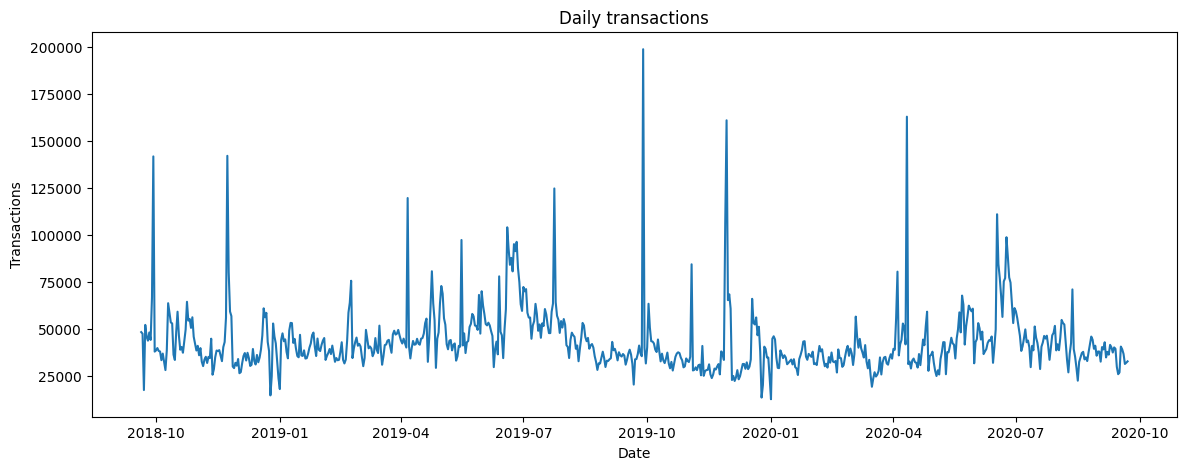

In [29]:
plt.figure(figsize=(14, 5))
plt.plot(daily_transactions["t_dat"], daily_transactions["transactions"])
plt.xlabel("Date")
plt.ylabel("Transactions")
plt.title("Daily transactions")
plt.show()

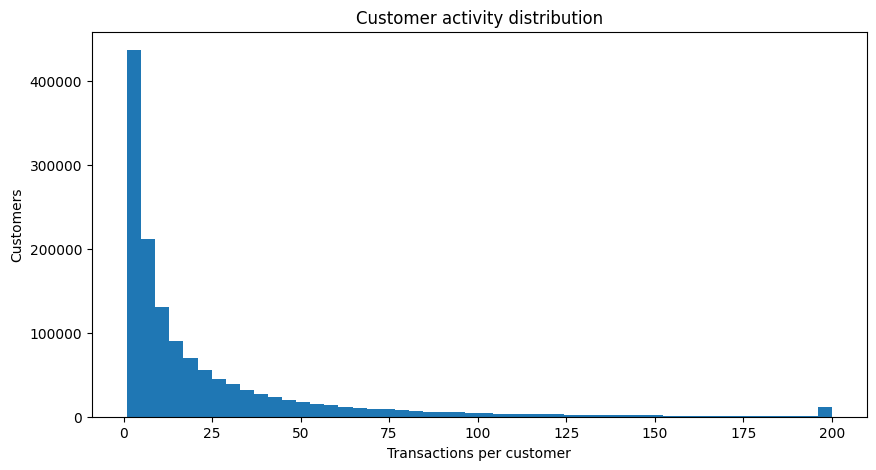

In [30]:
plt.figure(figsize=(10, 5))
plt.hist(user_activity["transactions"].clip(upper_bound=200), bins=50)
plt.xlabel("Transactions per customer")
plt.ylabel("Customers")
plt.title("Customer activity distribution")
plt.show()

In [31]:
PARQUET_PATH = PROCESSED_PATH / "transactions.parquet"

if not PARQUET_PATH.exists():
    transactions.sink_parquet(PARQUET_PATH, compression="zstd")

print(f"Parquet size: {PARQUET_PATH.stat().st_size / 1024**3:.2f} GB")

Parquet size: 0.40 GB


In [32]:
transactions = pl.scan_parquet(PARQUET_PATH)

In [33]:
transactions.head().collect()

t_dat,customer_id,article_id,price,sales_channel_id
date,str,i32,f32,i8
2018-09-20,"""000058a12d5b43e67d225668fa1f8d…",663713001,0.050831,2
2018-09-20,"""000058a12d5b43e67d225668fa1f8d…",541518023,0.030492,2
2018-09-20,"""00007d2de826758b65a93dd24ce629…",505221004,0.015237,2
2018-09-20,"""00007d2de826758b65a93dd24ce629…",685687003,0.016932,2
2018-09-20,"""00007d2de826758b65a93dd24ce629…",685687004,0.016932,2


In [34]:
from datetime import date

VAL_START = date(2020, 9, 9)
TEST_START = date(2020, 9, 16)

In [35]:
split_stats = (
    transactions
    .with_columns(
        pl.when(pl.col("t_dat") < VAL_START).then(pl.lit("train"))
        .when(pl.col("t_dat") < TEST_START).then(pl.lit("validation"))
        .otherwise(pl.lit("test"))
        .alias("split")
    )
    .group_by("split")
    .agg(
        pl.len().alias("transactions"),
        pl.col("customer_id").n_unique().alias("customers"),
        pl.col("article_id").n_unique().alias("articles")
    )
    .collect()
)

split_stats

split,transactions,customers,articles
str,u32,u32,u32
"""test""",240311,68984,17986
"""validation""",255241,72019,18611
"""train""",31292772,1351314,102967


In [36]:
train_user_activity = (
    transactions
    .filter(pl.col("t_dat") < VAL_START)
    .group_by("customer_id")
    .agg(pl.len().alias("transactions"))
    .collect()
)

In [37]:
train_user_activity.select(
    (pl.col("transactions") >= 2).sum().alias("at_least_2"),
    (pl.col("transactions") >= 3).sum().alias("at_least_3"),
    (pl.col("transactions") >= 5).sum().alias("at_least_5"),
    (pl.col("transactions") >= 10).sum().alias("at_least_10")
)

at_least_2,at_least_3,at_least_5,at_least_10
u32,u32,u32,u32
1221097,1094866,918541,670171


In [38]:
train_users = transactions.filter(pl.col("t_dat") < VAL_START).select("customer_id").unique()
val_users = transactions.filter((pl.col("t_dat") >= VAL_START) & (pl.col("t_dat") < TEST_START)).select("customer_id").unique()

val_users.join(train_users, on="customer_id", how="semi").select(pl.len().alias("with_history")).collect()

with_history
u32
66624


In [39]:
history_users = transactions.filter(pl.col("t_dat") < TEST_START).select("customer_id").unique()
test_users = transactions.filter(pl.col("t_dat") >= TEST_START).select("customer_id").unique()

test_users.join(history_users, on="customer_id", how="semi").select(pl.len().alias("with_history")).collect()

with_history
u32
63412


In [40]:
train_items = transactions.filter(pl.col("t_dat") < VAL_START).select("article_id").unique()
val_items = transactions.filter((pl.col("t_dat") >= VAL_START) & (pl.col("t_dat") < TEST_START)).select("article_id").unique()

val_new_items = val_items.join(train_items, on="article_id", how="anti")

print("Товаров в validation:", val_items.select(pl.len()).collect().item())
print("Новых товаров в validation:", val_new_items.select(pl.len()).collect().item())

Товаров в validation: 18611
Новых товаров в validation: 913


In [41]:
history_items = transactions.filter(pl.col("t_dat") < TEST_START).select("article_id").unique()
test_items = transactions.filter(pl.col("t_dat") >= TEST_START).select("article_id").unique()

test_new_items = test_items.join(history_items, on="article_id", how="anti")

print("Товаров в test:", test_items.select(pl.len()).collect().item())
print("Новых товаров в test:", test_new_items.select(pl.len()).collect().item())

Товаров в test: 17986
Новых товаров в test: 667


In [42]:
val_new_transactions = (
    transactions
    .filter((pl.col("t_dat") >= VAL_START) & (pl.col("t_dat") < TEST_START))
    .join(val_new_items, on="article_id", how="semi")
    .select(pl.len())
    .collect()
    .item()
)

test_new_transactions = (
    transactions
    .filter(pl.col("t_dat") >= TEST_START)
    .join(test_new_items, on="article_id", how="semi")
    .select(pl.len())
    .collect()
    .item()
)

print("Покупок новых товаров в validation:", val_new_transactions)
print("Покупок новых товаров в test:", test_new_transactions)

Покупок новых товаров в validation: 13361
Покупок новых товаров в test: 9564


In [43]:
val_total = val_users.select(pl.len()).collect().item()
val_with_history = val_users.join(train_users, on="customer_id", how="semi").select(pl.len()).collect().item()

test_total = test_users.select(pl.len()).collect().item()
test_with_history = test_users.join(history_users, on="customer_id", how="semi").select(pl.len()).collect().item()

print("Validation users without history:", val_total - val_with_history)
print("Test users without history:", test_total - test_with_history)

Validation users without history: 5395
Test users without history: 5572


In [44]:
metadata_columns = [
    "product_type_name",
    "product_group_name",
    "graphical_appearance_name",
    "colour_group_name",
    "department_name",
    "index_name",
    "section_name",
    "garment_group_name"
]

for column in metadata_columns:
    print(column, articles[column].nunique())

product_type_name 131
product_group_name 19
graphical_appearance_name 30
colour_group_name 50
department_name 250
index_name 10
section_name 56
garment_group_name 21
